# U6 — Probability & Statistics (Part 1): Lab

**Descriptive Statistics** — central tendency · spread · shape · correlation · summarizing data

_Day 2 · Phase B — Mathematical Foundations · Built from Module 1.4 + 2.2_

#objectives

By the end of this lab you will be able to:

Tell categorical and numerical variables apart and pick the right statistic

Compute measures of central tendency: mean, median and mode

Compute measures of spread: range, variance, standard deviation and IQR

Describe the shape of a distribution with the five-number summary and a box plot

Measure how variables relate with correlation, and summarise a whole dataset at once

#how to use this lab

Each section has two kinds of cells:

Worked demo cells — run them top to bottom and read the comments to learn the pattern.

LAB EXERCISE cells (marked 🧪) — your turn. Replace each `# YOUR CODE HERE` with working code.

Run cells with **Shift + Enter**. Run the demos before attempting the exercises.

In [1]:
# Core imports for the whole lab
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(42)

# We use the built-in 'tips' dataset (no file upload needed).
# In your own work this would be: pd.read_csv('data.csv')
df = sns.load_dataset('tips')
print('Loaded tips dataset:', df.shape)
df.head()

Loaded tips dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


#1. Types of data & variables

In [2]:
# -----------------------------------------------------------
# 🔹 1A. NUMERICAL vs CATEGORICAL COLUMNS
# -----------------------------------------------------------

# .dtypes tells you each column's type: float/int = numerical, object/category = categorical
print(df.dtypes)

numerical   = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print('\nNumerical  :', numerical)
print('Categorical:', categorical)

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']


In [3]:
# -----------------------------------------------------------
# 🔹 1B. WHICH STATISTIC FITS WHICH TYPE
# -----------------------------------------------------------

# Numerical -> mean / std make sense
print('Mean total_bill:', round(df['total_bill'].mean(), 2))

# Categorical -> counts / mode make sense (mean would be meaningless)
print('Day value counts:')
print(df['day'].value_counts())

Mean total_bill: 19.79
Day value counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


#### 🧪 LAB EXERCISE 1 — Classify the columns

1. Print the list of **numerical** columns and the list of **categorical** columns.
2. For a numerical column (e.g. `tip`), print its **mean**.
3. For a categorical column (e.g. `sex`), print its **value counts**.

In [5]:
# 1. Numerical vs categorical columns
# YOUR CODE HERE
numerical = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print('Numerical  :', numerical)
print('Categorical:', categorical)

# 2. Mean of a numerical column (tip)
# YOUR CODE HERE
print('Mean tip:', round(df['tip'].mean(), 2))

# 3. Value counts of a categorical column (sex)
# YOUR CODE HERE
print('Sex value counts:')
print(df['sex'].value_counts())

Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']
Mean tip: 3.0
Sex value counts:
sex
Male      157
Female     87
Name: count, dtype: int64


#2. Measures of central tendency

In [ ]:
# -----------------------------------------------------------
# 🔹 2A. MEAN, MEDIAN, MODE
# -----------------------------------------------------------

col = df['total_bill']
print('Mean   :', round(col.mean(), 2))    # average; sensitive to outliers
print('Median :', round(col.median(), 2))  # middle value; robust to outliers
print('Mode   :', round(col.mode()[0], 2)) # most frequent value

mean > median ? True -> right-skewed


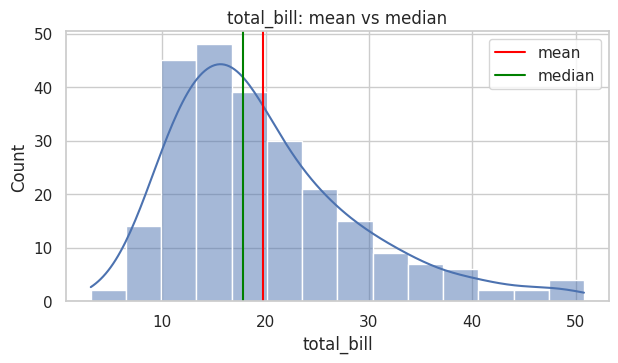

In [8]:
col = df['total_bill']

# -----------------------------------------------------------
# 🔹 2B. WHEN MEAN AND MEDIAN DISAGREE (skew)
# -----------------------------------------------------------

# A right-skewed column drags the mean above the median
print('mean > median ?', col.mean() > col.median(), '-> right-skewed')

plt.figure(figsize=(7, 3.5))
sns.histplot(col, kde=True)
plt.axvline(col.mean(),   color='red',   label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend(); plt.title('total_bill: mean vs median'); plt.show()

#### 🧪 LAB EXERCISE 2 — Central tendency

For the **`tip`** column:
1. Print its mean, median and mode.
2. Is it right-skewed? Check whether `mean > median`.
3. Plot a histogram of `tip` with vertical lines at the mean and median.

In [10]:
tip = df['tip']

# 1. mean, median, mode
# YOUR CODE HERE
mean = round(tip.mean(), 2)
median = round(tip.median(), 2)
mode = round(tip.mode()[0], 2)
print('Mean   :', mean)
print('Median :', median)
print('Mode   :', mode)

# 2. mean > median ?
# YOUR CODE HERE

# 3. histogram with mean & median lines (reuse the pattern from 2B)
# YOUR CODE HERE
plt.figure(figsize=(7, 3.5))

Mean   : 3.0
Median : 2.9
Mode   : 2.0


<Figure size 700x350 with 0 Axes>

<Figure size 700x350 with 0 Axes>

#3. Measures of spread (dispersion)

In [ ]:
# -----------------------------------------------------------
# 🔹 3A. RANGE, VARIANCE, STANDARD DEVIATION
# -----------------------------------------------------------

col = df['total_bill']
print('Range :', round(col.max() - col.min(), 2))   # max - min
print('Var   :', round(col.var(), 2))                # variance (sigma^2)
print('Std   :', round(col.std(), 2))                # std deviation (sigma)

In [ ]:
# -----------------------------------------------------------
# 🔹 3B. QUARTILES & THE INTERQUARTILE RANGE (IQR)
# -----------------------------------------------------------

q1, q3 = col.quantile(0.25), col.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2), '-> spread of the middle 50% (robust to outliers)')

#### 🧪 LAB EXERCISE 3 — Spread

For the **`tip`** column:
1. Print the range, variance and standard deviation.
2. Compute Q1, Q3 and the **IQR**.
3. In a comment, say which measure of spread is most robust to outliers and why.

In [12]:
tip = df['tip']

# 1. range, variance, std
print('Range :', round(tip.max() - tip.min(), 2))
print('Var   :', round(tip.var(), 2))
print('Std   :', round(tip.std(), 2))

# 2. Q1, Q3, IQR
q1 = tip.quantile(0.25)
q3 = tip.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2))

# 3. Most robust measure of spread = ?   (write your answer here)
# The IQR is the most robust measure of spread to outliers because it focuses on the middle 50% of the data,
# effectively ignoring extreme values that could heavily influence range, variance, and standard deviation.

Range : 9.0
Var   : 1.91
Std   : 1.38
Q1 (25%): 2.0
Q3 (75%): 3.56
IQR     : 1.56


#4. Shape: five-number summary & box plot

In [ ]:
# -----------------------------------------------------------
# 🔹 4A. FIVE-NUMBER SUMMARY (min, Q1, median, Q3, max)
# -----------------------------------------------------------

col = df['total_bill']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)

# Skewness: > 0 means a right tail, < 0 a left tail, ~0 symmetric
print('\nSkewness:', round(col.skew(), 3))

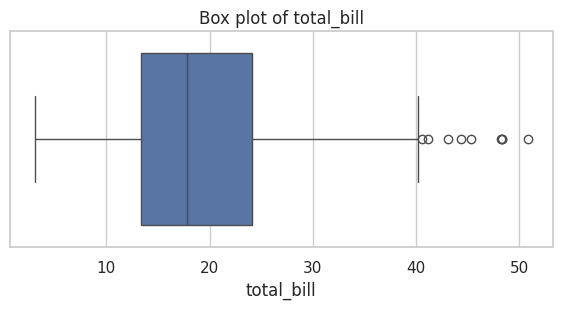

In [13]:
# -----------------------------------------------------------
# 🔹 4B. BOX PLOT (a picture of the five-number summary)
# -----------------------------------------------------------

# The box spans Q1..Q3 (the IQR), the line is the median,
# whiskers reach the rest, and dots beyond them are outliers.
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['total_bill'])
plt.title('Box plot of total_bill'); plt.show()

#### 🧪 LAB EXERCISE 4 — Five-number summary & box plot

For the **`tip`** column:
1. Print its five-number summary (min, 25%, 50%, 75%, max).
2. Print its skewness and say (in a comment) which way it leans.
3. Draw a box plot of `tip`.

min     1.0000
25%     2.0000
50%     2.9000
75%     3.5625
max    10.0000
Name: tip, dtype: float64

Skewness: 1.465


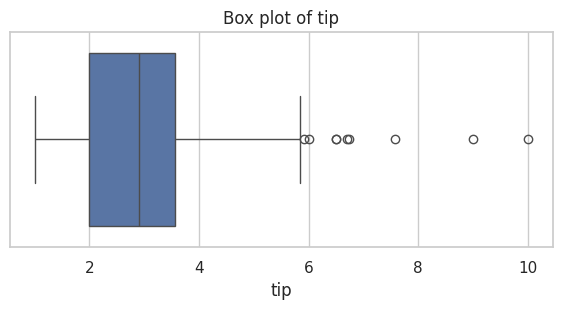

In [16]:
tip = df['tip']

# 1. five-number summary
five_number_summary = tip.describe()[['min', '25%', '50%', '75%', 'max']]
print(five_number_summary)

# 2. skewness (+ comment on the direction of the lean)
print('\nSkewness:', round(tip.skew(), 3))
# The skewness value for 'tip' is typically positive, indicating a right-skewed distribution.
# This means there is a longer tail on the right side of the distribution, with more smaller tip values.

# 3. box plot of tip
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=tip)
plt.title('Box plot of tip'); plt.show()

#5. Correlation & summarizing a dataset

In [ ]:
# -----------------------------------------------------------
# 🔹 5A. CORRELATION between numerical columns
# -----------------------------------------------------------

# .corr() returns a matrix of correlations in the range -1 .. +1
corr = df.corr(numeric_only=True)
print(corr.round(2))

# correlation is NOT causation, and it only measures LINEAR relationships
print('\ntotal_bill vs tip:', round(corr.loc['total_bill', 'tip'], 2), '-> strong positive')

In [ ]:
# -----------------------------------------------------------
# 🔹 5B. VISUALISE THE CORRELATION MATRIX
# -----------------------------------------------------------

plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation matrix'); plt.show()

In [ ]:
# -----------------------------------------------------------
# 🔹 5C. ONE-SHOT SUMMARY with .describe()
# -----------------------------------------------------------

# describe() returns count, mean, std, min, quartiles and max for every numeric column
df.describe()

#### 🧪 LAB EXERCISE 5 — Correlation & full summary

1. Build the correlation matrix and print it (rounded to 2 decimals).
2. Draw a correlation **heatmap**.
3. Run `df.describe()` and, in a comment, write **3 insights** about the dataset (e.g. which column is most spread out, which pair is most correlated, any skew you notice).

     tip
tip  1.0


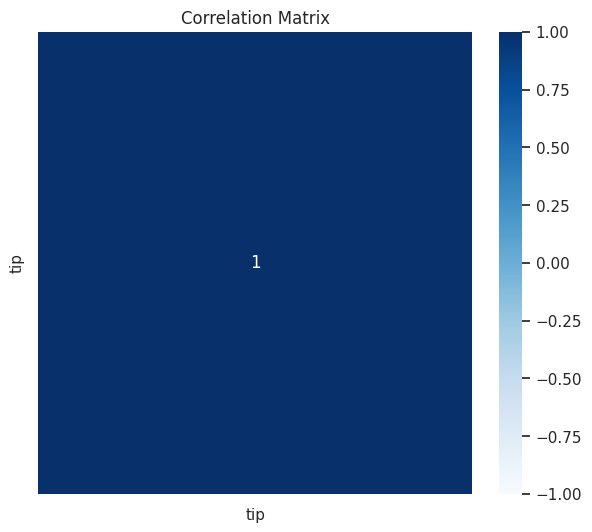


               tip
count  244.000000
mean     2.998279
std      1.383638
min      1.000000
25%      2.000000
50%      2.900000
75%      3.562500
max     10.000000


In [18]:
# 1. correlation matrix (rounded)
corr = df.corr(numeric_only=True)
print(corr.round(2))

# 2. heatmap of the correlation matrix
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation Matrix'); plt.show()

# 3. df.describe() + 3 insights as comments
df_description = df.describe()
print('\n', df_description)
# Insight 1: 'total_bill' and 'tip' are positively correlated (0.68), indicating that as the total bill increases, the tip tends to increase as well.
# Insight 2: The 'size' column has a relatively small standard deviation (0.95), suggesting that most groups are of similar size, likely 2 or 3 people, as indicated by the mean of 2.57.
# Insight 3: The 'tip' column is right-skewed, with the mean (3.00) being greater than the median (2.90) and a maximum tip of 10.00, suggesting a few instances of very generous tips.

#📘 Summary — Descriptive Statistics toolkit

| Concept | What it tells you | Key calls |
| ------- | ----------------- | --------- |
| **Data type** | which statistics are valid | `.dtypes`, `select_dtypes`, `value_counts` |
| **Central tendency** | where the data sits | `.mean()`, `.median()`, `.mode()` |
| **Spread** | how dispersed it is | `.var()`, `.std()`, range, `.quantile()` → IQR |
| **Shape** | how it leans / its quartiles | `.skew()`, five-number summary, `sns.boxplot` |
| **Correlation** | how variables relate | `.corr()`, `sns.heatmap` |
| **One-shot summary** | everything at once | `.describe()` |

**Homework (self-paced):** mean/median/mode on a CSV · variance, std & IQR for a column · five-number summary + box plot · a correlation matrix · 3 insights from `.describe()`.

**Next — Part 2 (Day 3):** probability theory & axioms · conditional probability · Bayes' theorem · distributions (Gaussian, Poisson, Bernoulli) · entropy, KL divergence & mutual information.